In [14]:
%load_ext dotenv
%dotenv /home/aurora/.env
%matplotlib inline

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [15]:
import numpy as np
import pandas as pd
import datetime as dt
from google.cloud import bigquery
import re
import pymongo
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from flatten_json import flatten
#warnings.filterwarnings('ignore')

In [16]:
# Time
start = dt.datetime(2019,4,10)
end = dt.datetime(2019,4,15)
print(start,end,end-start)

2019-04-10 00:00:00 2019-04-15 00:00:00 5 days, 0:00:00


In [17]:
cursor = pymongo.MongoClient("mongodb://" + os.environ['user'] + ':' + 
                             os.environ['pass'] + '@' + os.environ['db1']  + "/?authSource=" + 
                             os.environ['dbname'])
c_users = cursor.superstars.users
aw = []
for documents in c_users.find({'created_at': {'$lt': end, '$gte': start}},{"sign_up_details":1, "created_at":1,"login_details":1}):
    aw.append(documents)
dic_flattened = [flatten(d) for d in aw]
df = pd.DataFrame(dic_flattened)
df = df[df["sign_up_details_app_platform"] == "UNITY_Android"]
#df = df[df["sign_up_details_device_id"].isin(devices)]
users = df[["_id","created_at","sign_up_details_device_height","sign_up_details_device_width","login_details_last_request_at"]]
users.columns = ["user_id","createtime","height","width","last_request"]
users['aratio'] = (users['height']/users['width'])
users.head()

/home/aurora/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


,user_id,createtime,height,width,last_request,aratio
0,5cad322cfe2b78557335ca62,2019-04-10 00:00:44.041,1440,720,2019-04-10 00:25:12.225,2.000000
1,5cad32395e8abf05f7f03b9f,2019-04-10 00:00:57.504,2184,1080,2019-04-10 00:04:42.073,2.022222
2,5cad326a465f3e05f85e6461,2019-04-10 00:01:46.147,1440,720,2019-04-10 11:03:42.294,2.000000
3,5cad32b4aa650c557a821c2d,2019-04-10 00:03:00.342,1280,720,2019-04-10 00:07:35.409,1.777778
4,5cad32b9cbac707336e4b065,2019-04-10 00:03:05.866,1440,720,2019-04-10 00:06:44.447,2.000000


In [18]:
team_cursor = cursor.superstars.teams
aw = []
for documents in team_cursor.find({'created_at': {'$gte': start}}):
    aw.append(documents)
dic_flattened = [flatten(d) for d in aw]
df = pd.DataFrame(dic_flattened)
df.head()
teams = df[df["user"].isin(users["user_id"])]
teams = teams[["_id","user","entry_league"]]
teams.columns = ["team_id", "user_id", "entry league"]
teams.head()
print(len(teams))

46544


In [19]:
dm = pd.merge(users,teams,on='user_id',how='inner')
dm.head()

,user_id,createtime,height,width,last_request,aratio,team_id,entry league
0,5cad322cfe2b78557335ca62,2019-04-10 00:00:44.041,1440,720,2019-04-10 00:25:12.225,2.000000,5cad322cfe2b78557335ca66,NaN
1,5cad32395e8abf05f7f03b9f,2019-04-10 00:00:57.504,2184,1080,2019-04-10 00:04:42.073,2.022222,5cad32395e8abf05f7f03ba3,NaN
2,5cad326a465f3e05f85e6461,2019-04-10 00:01:46.147,1440,720,2019-04-10 11:03:42.294,2.000000,5cad326a465f3e05f85e6465,NaN
3,5cad32b4aa650c557a821c2d,2019-04-10 00:03:00.342,1280,720,2019-04-10 00:07:35.409,1.777778,5cad32b4aa650c557a821c31,NaN
4,5cad32b9cbac707336e4b065,2019-04-10 00:03:05.866,1440,720,2019-04-10 00:06:44.447,2.000000,5cad32b9cbac707336e4b069,NaN


In [20]:
dm['d1'] = (dm['last_request']-dm['createtime'])>'24:00:00'
dm['d3'] = (dm['last_request']-dm['createtime'])>'72:00:00'
dm['d7'] = (dm['last_request']-dm['createtime'])>'168:00:00'
dm.head()

,user_id,createtime,height,width,last_request,aratio,team_id,entry league,d1,d3,d7
0,5cad322cfe2b78557335ca62,2019-04-10 00:00:44.041,1440,720,2019-04-10 00:25:12.225,2.000000,5cad322cfe2b78557335ca66,NaN,False,False,False
1,5cad32395e8abf05f7f03b9f,2019-04-10 00:00:57.504,2184,1080,2019-04-10 00:04:42.073,2.022222,5cad32395e8abf05f7f03ba3,NaN,False,False,False
2,5cad326a465f3e05f85e6461,2019-04-10 00:01:46.147,1440,720,2019-04-10 11:03:42.294,2.000000,5cad326a465f3e05f85e6465,NaN,False,False,False
3,5cad32b4aa650c557a821c2d,2019-04-10 00:03:00.342,1280,720,2019-04-10 00:07:35.409,1.777778,5cad32b4aa650c557a821c31,NaN,False,False,False
4,5cad32b9cbac707336e4b065,2019-04-10 00:03:05.866,1440,720,2019-04-10 00:06:44.447,2.000000,5cad32b9cbac707336e4b069,NaN,False,False,False


In [21]:
f = {'user_id':'count','entry league':'count','d1':'sum','d3':'sum','d7':'sum'}
a = dm.groupby('aratio').agg(f)
a.sort_values('user_id',ascending=False,inplace=True)
a['entry league'] = a['entry league']/a['user_id']
a['d1'] = a['d1']/a['user_id']
a['d3'] = a['d3']/a['user_id']
a['d7'] = a['d7']/a['user_id']
a[['entry league','d1','d3','d7']] = (a[['entry league','d1','d3','d7']]*100).round()
a.rename(columns={'user_id':'no of users','entry league':'league joined %','d1':'d1 %','d3':'d3 %','d7':'d7 %'}, inplace=True)
print(len(a))
a.head()


68


,no of users,league joined %,d1 %,d3 %,d7 %
aratio,,,,,
1.777778,27728,5.0,18.0,10.0,6.0
2.000000,10172,6.0,19.0,11.0,7.0
2.111111,1448,4.0,19.0,11.0,7.0
2.022222,1246,6.0,20.0,12.0,7.0
2.033333,1202,6.0,20.0,13.0,9.0


KeyError: 0.0

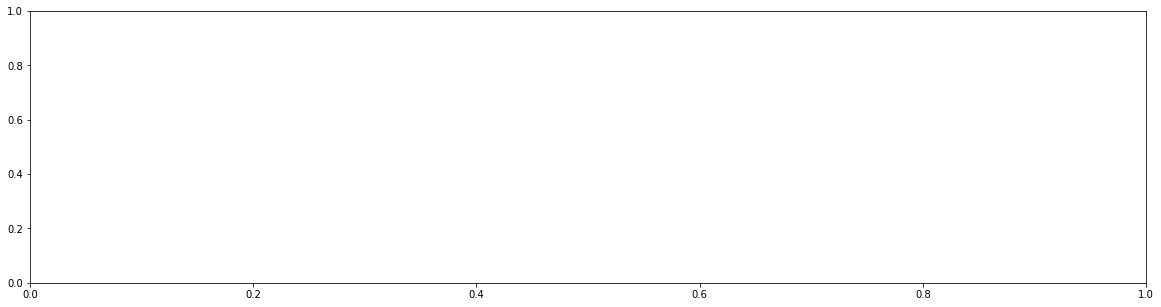

In [22]:
fig, axs = plt.subplots(figsize = (20, 5))
b = a[0:10]
b = b.reset_index()
sns.lineplot(x="", y='d1 %',  data=b, ax = axs,label='d1 %')
sns.lineplot(x="aratio", y='d3 %',  data=b, ax = axs,label = 'd3 %')
sns.lineplot(x="aratio", y='d7 %',  data=b, ax = axs,label = 'd7 %')
sns.lineplot(x="aratio", y='league joined %',  data=b, ax = axs, label = 'league joined %')
axs.set_ylabel('percentage')
#axs.set_ylabel('percentage')
plt.show()